# Figure 2 and appendix figures: well-specified simulation (R1)

Reads the per-replication rows written by

```bash
python experiments/simulation/r1_main.py --config main10     --row both --seeds 0:50 --workers 6
python experiments/simulation/r1_main.py --config app20      --row both --seeds 0:50 --workers 6
python experiments/simulation/r1_main.py --config main10_mis --row both --seeds 0:50 --workers 6
```

and renders the two-row main figure (`figures/r1_main10.pdf`), the $N=20$ replicate (`r1_app20.pdf`), and the misaligned-target appendix figure (`r1_main10_mis.pdf`) with the unified method panel of `experiments/style.py`.
The human target is $s_0=\alpha_0\mu$ in `main10` and `app20` (aligned with the consensus, $c_V=0$) and $s_0=Wc_0$ with $c_V\sim N(0,0.5^2)$ in `main10_mis`.

In [1]:
import sys
from pathlib import Path
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np, pandas as pd

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.simulation.r1_plot import COLS, aggregate, load  # noqa: E402
from experiments.style import PRESENTED_W, LABEL, STYLE, INK_SOFT, GRID, RCPARAMS, legend_handles, method_lines  # noqa: E402
FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
mpl.rcParams.update(RCPARAMS)  # same serif family and sizes as the real-data figures

PANELS = [  # (column in rows.jsonl, panel title, log y)
    ("excess", "excess human risk", True),
    ("kendall", r"Kendall $\tau(\hat s, s_0)$", False),
    ("cov_s", "95% CI coverage", False),
    ("b_rmse", r"RMSE$(\hat b, b)$", True),
]
NH = "$n_{\\mathrm{H}}$"  # human budget, as written in the manuscript


## Load and aggregate

`load` marks a replication irregular when the staged endpoint (Cons-Cal) or the fixed-weight joint fit is flagged as non-convergent (separation in a judge-item cell at the smallest LLM budgets); `aggregate` averages over the regular replications and counts the excluded ones.

In [2]:
frames = {}
for cfg in ("main10", "app20", "main10_mis"):
    path = REPO / "results" / "r1" / cfg / "rows.jsonl"
    if not path.exists():
        print(f"{cfg}: no rows at {path.relative_to(REPO)}; run r1_main.py first"); continue
    df = load(cfg, base=REPO); agg = aggregate(df); frames[cfg] = (df, agg)
    n_irr = int(df[df.irregular][["row", "n_L", "n_H", "seed"]].drop_duplicates().shape[0])
    print(f"{cfg}: N={int(df.N.iloc[0])}, K={int(df.K.iloc[0])}, r={int(df.r.iloc[0])}, c_v_sd={df.c_v_sd.iloc[0]}, seeds={df.seed.nunique()}, "
          f"cells={df[['row','n_L','n_H']].drop_duplicates().shape[0]}, irregular replications excluded={n_irr}, failed rows={int(df.get('error', pd.Series(dtype=object)).notna().sum()) if 'error' in df else 0}")


main10: N=10, K=4, r=1, c_v_sd=0.0, seeds=50, cells=11, irregular replications excluded=0, failed rows=0
app20: N=20, K=6, r=2, c_v_sd=0.0, seeds=50, cells=11, irregular replications excluded=0, failed rows=0


main10_mis: N=10, K=4, r=1, c_v_sd=0.5, seeds=50, cells=11, irregular replications excluded=0, failed rows=0


## Figure

Drawn at the ICLR text-block width (5.5 in) so fonts are true size. Pooled and DIAL-noPos appear in the RMSE$(\hat b, b)$ panel at their implied $\hat b = 0$, so the panel shows what ignoring display order costs rather than leaving a gap. Theory lines in the top-left panel: $(N-1)/(2n_{\mathrm{H}})$ for human-only BTL and $1/(2n_{\mathrm{H}})$ for calibration of the single coefficient $\alpha$ within $\operatorname{span}(\mu)$ (Theorem `thm:population-risk-tradeoff` with $d=1$); the third line is $(r+1)/(2n_{\mathrm{H}})$ for DIAL-$W$, which calibrates the $r+1$ coordinates of $W=[\mu,V]$ (Theorem `thm:fixed-space-tradeoff` with $d=r+1$) and is the anchored line for the misaligned target.

saved figures/r1_main10.pdf (50 seeds)


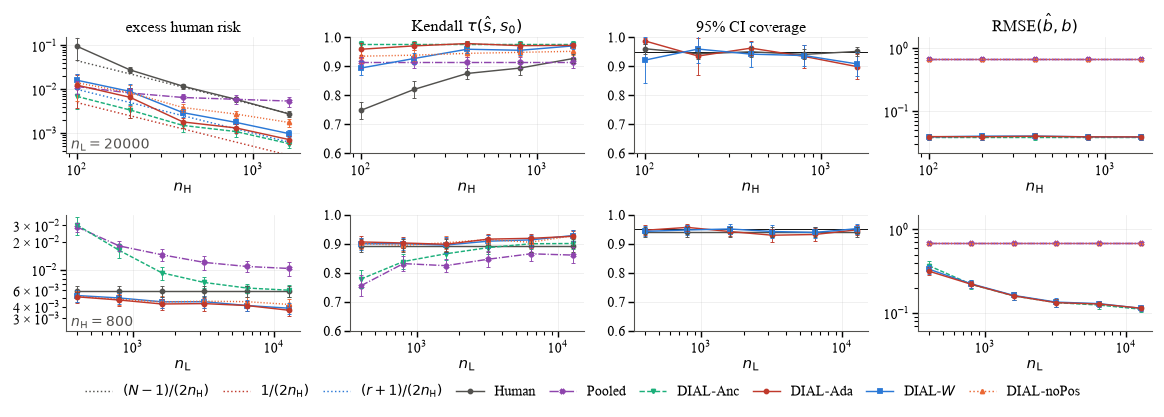

saved figures/r1_app20.pdf (50 seeds)


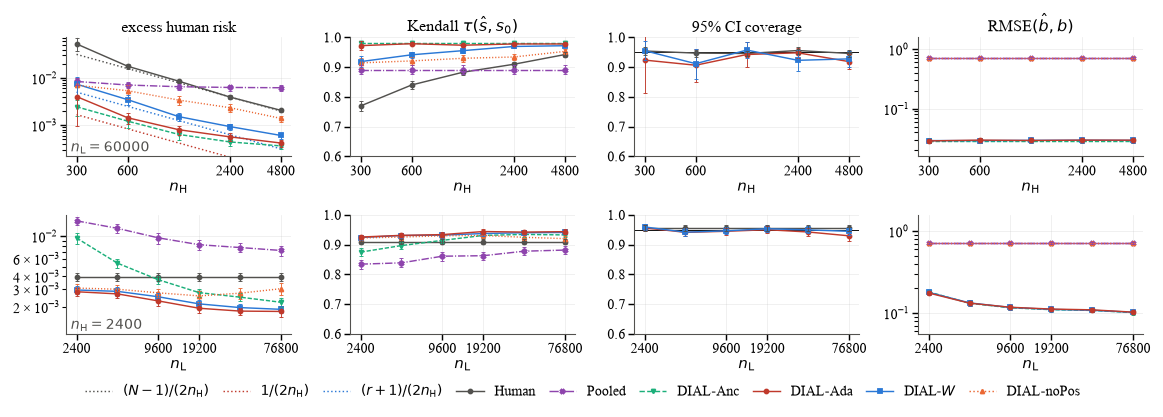

In [3]:
def halos(ax, d, xcol, ycol, methods, lw):
    """Curves that coincide exactly (Pooled and DIAL-noPos both impose b = 0) would hide one
    another, so the first of each coinciding group gets a wide halo underneath."""
    seen = {}
    for m in methods:
        g = d[d.method == m].sort_values(xcol)
        y = g[ycol].to_numpy(dtype=float)
        if len(y) == 0 or np.all(np.isnan(y)):
            continue
        key = tuple(np.round(y, 12))
        if key in seen:
            ax.plot(g[xcol], y, lw=lw * 3.2, alpha=0.9, solid_capstyle="round", color=STYLE[seen[key]]["color"], ls="-", zorder=1.5)
        else:
            seen[key] = m


def draw(agg, N, r, out, seeds, methods, theory_dims, extra=(), n_xticks=None, labels=None):
    fig, axes = plt.subplots(2, len(PANELS), figsize=(9, 3))
    ms, lw = 2.2, 0.8
    shown = list(methods) + list(extra)
    for ri, (row, xcol, xlabel) in enumerate([("nH", "n_H", NH), ("nL", "n_L", "$n_{\mathrm{L}}$")]):
        d = agg[agg.row == row]
        for ci, (col, title, logy) in enumerate(PANELS):
            ax = axes[ri, ci]
            if col == "excess" and row == "nH":
                x = np.array(sorted(d[xcol].unique()), float)
                for dim, lab, color in theory_dims:
                    ax.plot(x, dim / (2 * x), ":", color=color, lw=lw)
            halos(ax, d, xcol, f"{col}_mean", shown, lw)
            method_lines(ax, d, xcol, f"{col}_mean", shown, se=f"{col}_se", caps=True, ms=ms, lw=lw, emphasize=("dial_mu",))
            if col == "cov_s": ax.axhline(0.95, color="k", lw=0.5, zorder=1); ax.set_ylim(0.6, 1.0)
            if col == "kendall": ax.set_ylim(min(0.6, ax.get_ylim()[0]), 1.0)
            if col == "excess":
                lo = np.nanmin(d[d.method.isin(methods)][f"{col}_mean"].values); ax.set_ylim(lo * 0.6, ax.get_ylim()[1])
            if col == "b_rmse":  # the b-hat = 0 rows of Pooled and DIAL-noPos are ~20x the fitted errors, so set the span from the data
                v = d[d.method.isin(methods)][f"{col}_mean"].dropna()
                if len(v): ax.set_ylim(float(v.min()) * 0.55, float(v.max()) * 2.2)
            ax.set_xscale("log")
            if n_xticks is not None:
                # pick n_xticks evenly spaced (in log) from actual data values
                xvals = np.array(sorted(d[xcol].unique()), float)
                idx = np.round(np.linspace(0, len(xvals) - 1, min(n_xticks, len(xvals)))).astype(int)
                ax.xaxis.set_major_locator(mpl.ticker.FixedLocator(xvals[idx]))
                ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
                ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
            if logy: ax.set_yscale("log")
            ax.set_xlabel(xlabel, labelpad=1)
            if ri == 0: ax.set_title(title, pad=3)
            ax.grid(alpha=0.25, which="major", lw=0.4); ax.tick_params(which="both", pad=1.5, labelsize=8)
            for sp in ("top", "right"): ax.spines[sp].set_visible(False)
        fixed = f"$n_{{\\mathrm{{L}}}}={int(d.n_L.iloc[0])}$" if row == "nH" else f"$n_{{\\mathrm{{H}}}}={int(d.n_H.iloc[0])}$"
        axes[ri, 0].annotate(fixed, xy=(0.02, 0.04), xycoords="axes fraction", fontsize=8, color=INK_SOFT)
    h, l = legend_handles(shown, labels=labels, ms=ms, lw=lw, extra_first=True,
                          extra=[(lab, dict(color=color, ls=":", lw=lw)) for _, lab, color in theory_dims])
    nc = min(len(l), 9); yoff = -0.06 if len(l) <= nc else -0.12  # a wrapped legend needs room below the x labels
    fig.legend(h, l, loc="lower center", ncol=nc, frameon=False, bbox_to_anchor=(0.5, yoff), handlelength=2.0, columnspacing=1.0)
    fig.tight_layout()
    fig.savefig(out, bbox_inches="tight", dpi=300)
    print("saved", out.relative_to(REPO), f"({seeds} seeds)")
    return fig

THEORY = {"human_only": "$(N-1)/(2n_{\\mathrm{H}})$", "dial_mu": "$1/(2n_{\\mathrm{H}})$", "dial_w": "$(r+1)/(2n_{\\mathrm{H}})$"}

for cfg in ("main10", "app20"):
    if cfg not in frames: continue
    df, agg = frames[cfg]; N, r = int(df.N.iloc[0]), int(df.r.iloc[0])
    theory = [(dim, THEORY[m], STYLE[m]["color"]) for dim, m in ((N - 1, "human_only"), (1, "dial_mu"), (r + 1, "dial_w"))]
    fig = draw(agg, N, r, FIGURES / f"r1_{cfg}.pdf", df.seed.nunique(), PRESENTED_W, theory,
               n_xticks=4 if cfg == "app20" else None); plt.show()


## Appendix: misaligned human target

`main10_mis` keeps $c_V\ne0$, so the human target has a component in $\operatorname{col}(V)$ that only the $W$-calibration can recover: DIAL-$\mu$ and Cons-Cal plateau at $\Delta_\mu$, DIAL-$W$ reaches the $(r+1)/(2n_{\mathrm{H}})$ line. This is the regime the three benchmarks do not exhibit.

saved figures/r1_main10_mis.pdf (50 seeds)


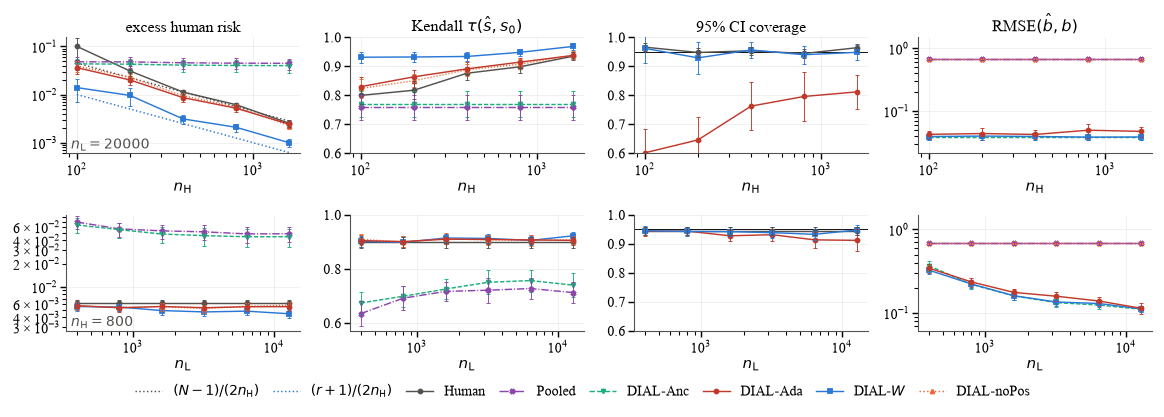

In [4]:
if "main10_mis" in frames:
    df, agg = frames["main10_mis"]; N, r = int(df.N.iloc[0]), int(df.r.iloc[0])
    theory = [(dim, THEORY[m], STYLE[m]["color"]) for dim, m in ((N - 1, "human_only"), (r + 1, "dial_w"))]
    fig = draw(agg, N, r, FIGURES / "r1_main10_mis.pdf", df.seed.nunique(), PRESENTED_W, theory); plt.show()


## Numbers quoted in the paper

In [5]:
for cfg, (df, agg) in frames.items():
    print(f"== {cfg}")
    show = ["row", "n_L", "n_H", "method", "n", "excess_mean", "excess_se", "kendall_mean", "cov_s_mean", "b_rmse_mean", "lam_med", "lam_zero_frac", "lam_inf_frac", "n_irregular"]
    print(agg[agg.method.isin(PRESENTED_W)][show].round(4).to_string(index=False))
if "main10" in frames:
    df, _ = frames["main10"]
    d = df[(df.row == "nH") & (df.method.isin(["dial_mu", "dial_mle_mu", "consensus_cal"])) & (~df.irregular)]
    print("\nmean vs median excess, top row:"); print(d.groupby(["n_H", "method"]).excess.agg(mean="mean", median="median", q90=lambda x: x.quantile(0.9)).round(4))
    sel0 = df[(df.method == "dial_mu") & (df.lam == 0)][["row", "n_L", "n_H", "seed", "excess"]]
    print(f"\nreplications with lambda_hat = 0: {len(sel0)}")


== main10
row   n_L  n_H        method  n  excess_mean  excess_se  kendall_mean  cov_s_mean  b_rmse_mean  lam_med  lam_zero_frac  lam_inf_frac  n_irregular
 nH 20000  100 consensus_cal 50       0.0069     0.0017        0.9778         NaN       0.0385      NaN           0.00          1.00          0.0
 nH 20000  100       dial_mu 50       0.0125     0.0045        0.9591      0.9878       0.0392  20.0000           0.04          0.56          0.0
 nH 20000  100    dial_nodeb 50       0.0141     0.0044        0.9351         NaN       0.6789  20.0000           0.04          0.56          0.0
 nH 20000  100        dial_w 50       0.0161     0.0031        0.8942      0.9216       0.0388  20.0000           0.02          0.60          0.0
 nH 20000  100    human_only 50       0.0961     0.0253        0.7484      0.9609          NaN   0.0000           1.00          0.00          0.0
 nH 20000  100    pooled_cal 50       0.0116     0.0019        0.9138         NaN       0.6789      NaN           